In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TIME_OFFSET = 10800 #ADT to UTC is 3hrs

In [ ]:
def process_file(k, input_csv, output_csv):
    print(f"Processing {input_csv}...")

    df = pd.read_csv(input_csv)

    df["timestamp"] = df["frame.time_epoch"] + TIME_OFFSET

    # Sort for IAT calculation
    df = df.sort_values("timestamp")

    df["time_window"] = (df["timestamp"]*k).astype(int) #we basically rounded down all the time-stamps in the granularity of 100mseconds

    df["iat"] = df.groupby(["ip.src", "ip.dst"])["timestamp"].diff().fillna(0) #this basically finds the inter-arrival time for src-dst pairs

    flows = df.groupby(
        ["time_window", "ip.src", "ip.dst"]
    ).agg(
        packet_count=("frame.len", "count"),
        total_bytes=("frame.len", "sum"),
        mean_packet_size=("frame.len", "mean"),
        std_packet_size=("frame.len", "std"),
        iat_mean=("iat", "mean"),
        iat_std=("iat", "std"),
        unique_func_codes=("modbus.func_code", "nunique"),
        exception_count=("modbus.exception_code", lambda x: x.notna().sum())
    ).reset_index()

    flows = flows.fillna(0)

    packets_per_window = flows.groupby("time_window")["packet_count"].sum().sort_index()

    plt.figure()
    plt.plot(packets_per_window.index - packets_per_window.index.min(), packets_per_window.values)
    plt.xlabel(f"{1000/k:.2f} ms windows")
    plt.ylabel("Total Packets")
    plt.title("Packets per Time Window")
    plt.show()

    top_ips = flows["ip.dst"].value_counts().head(5).index

    fig, axes = plt.subplots(len(top_ips), 1, figsize=(10, 4*len(top_ips)), sharex=True)

    for i, ip in enumerate(top_ips):
        ip_data = flows[flows["ip.dst"] == ip]
        packets = ip_data.groupby("time_window")["packet_count"].sum().sort_index()

        axes[i].plot(packets.index - packets.index.min(), packets.values)
        axes[i].set_title(f"Packets per Window for {ip}")
        axes[i].set_ylabel("Packets")

    axes[-1].set_xlabel(f"{1000/k:.2f} ms windows")

    plt.tight_layout()
    plt.show()

    flows.to_csv(output_csv, index=False)
    print(f"Saved → {output_csv}\n")

Processing ../train/benign_nw.csv...


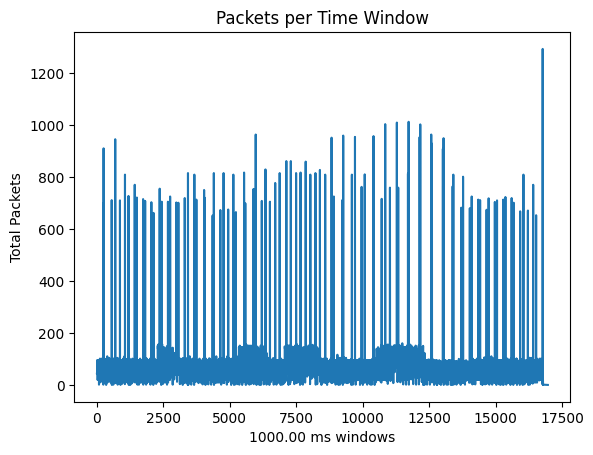

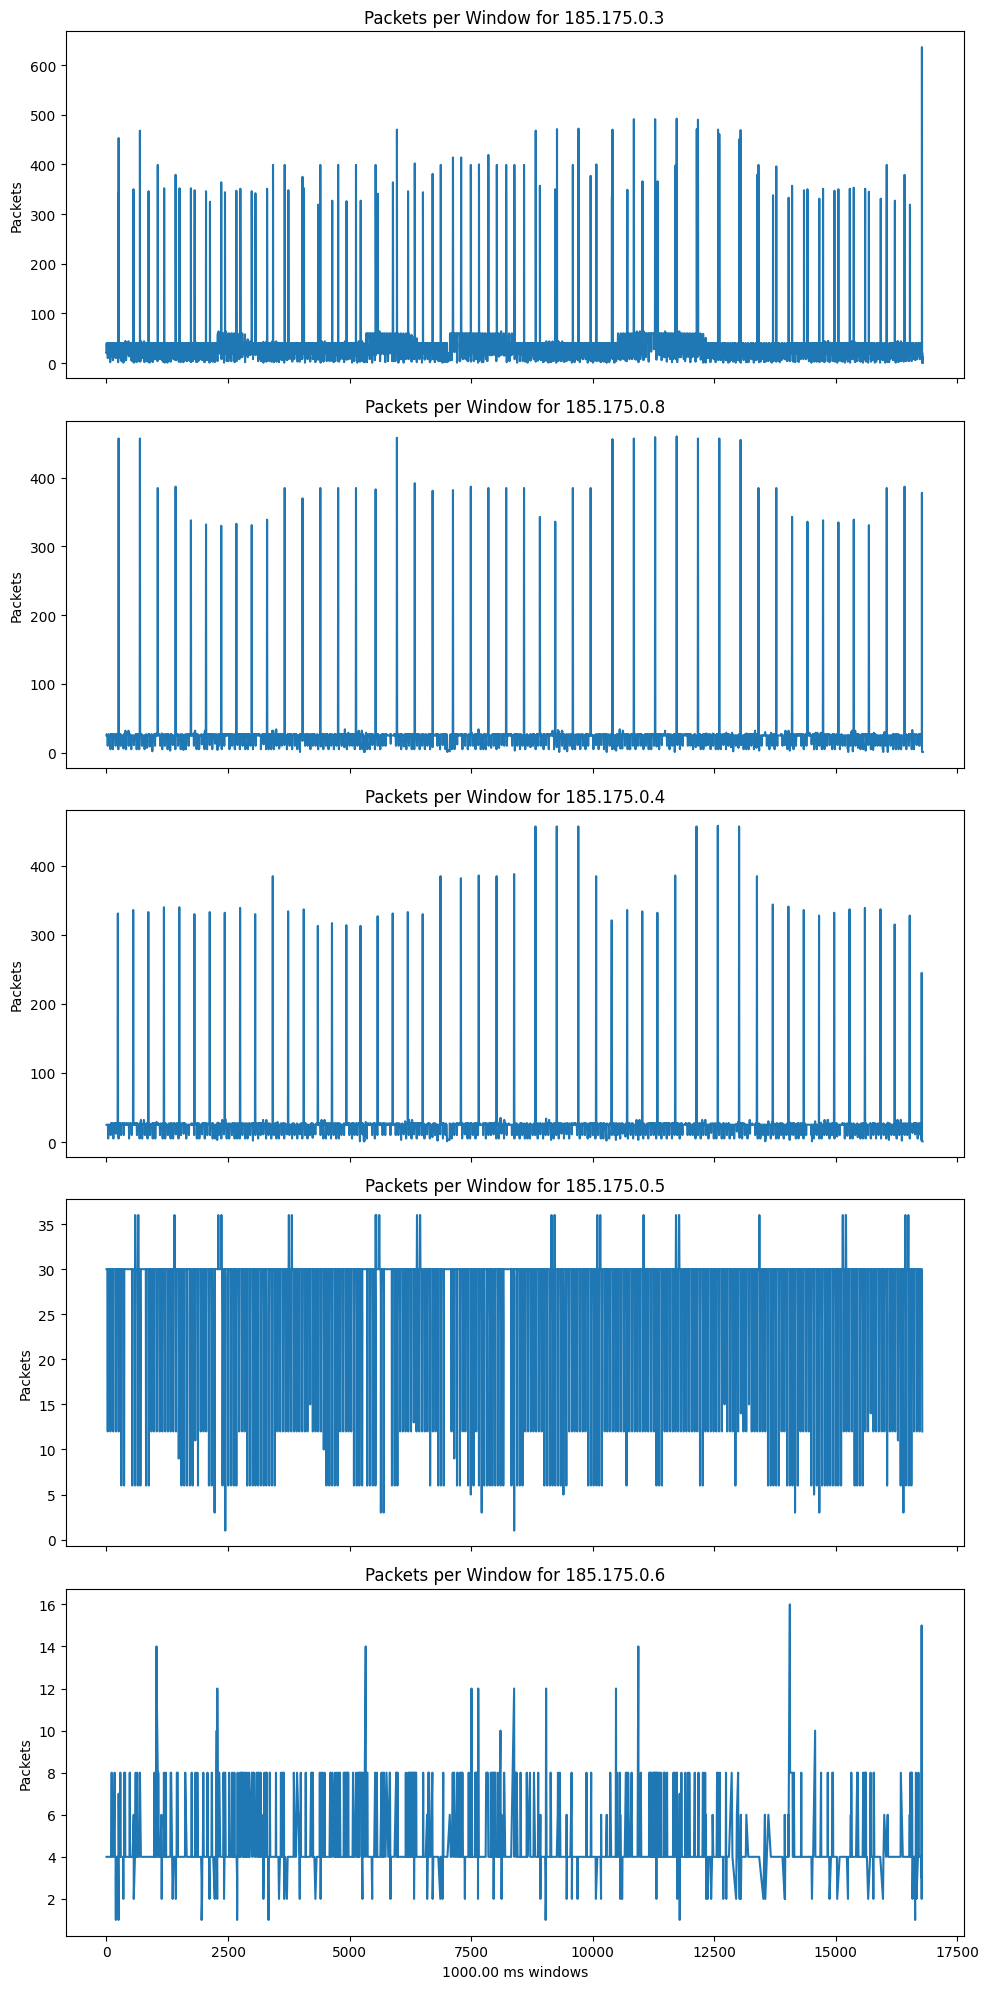

Saved → ../train/1s_benign_flows.csv



In [ ]:
process_file(1, "../train/benign_nw.csv", "../train/1s_benign_flows.csv")

Processing ../train/cscada_attack_ssw.csv...


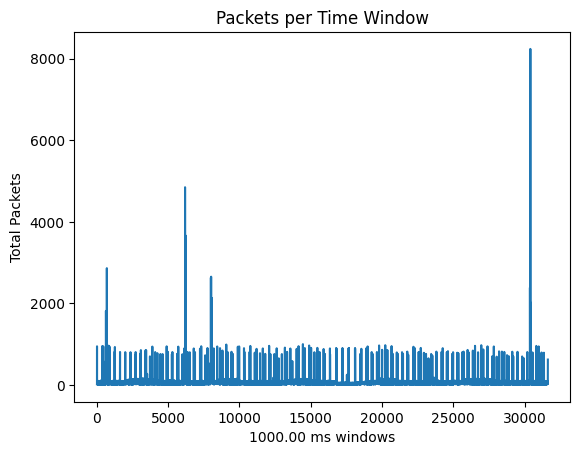

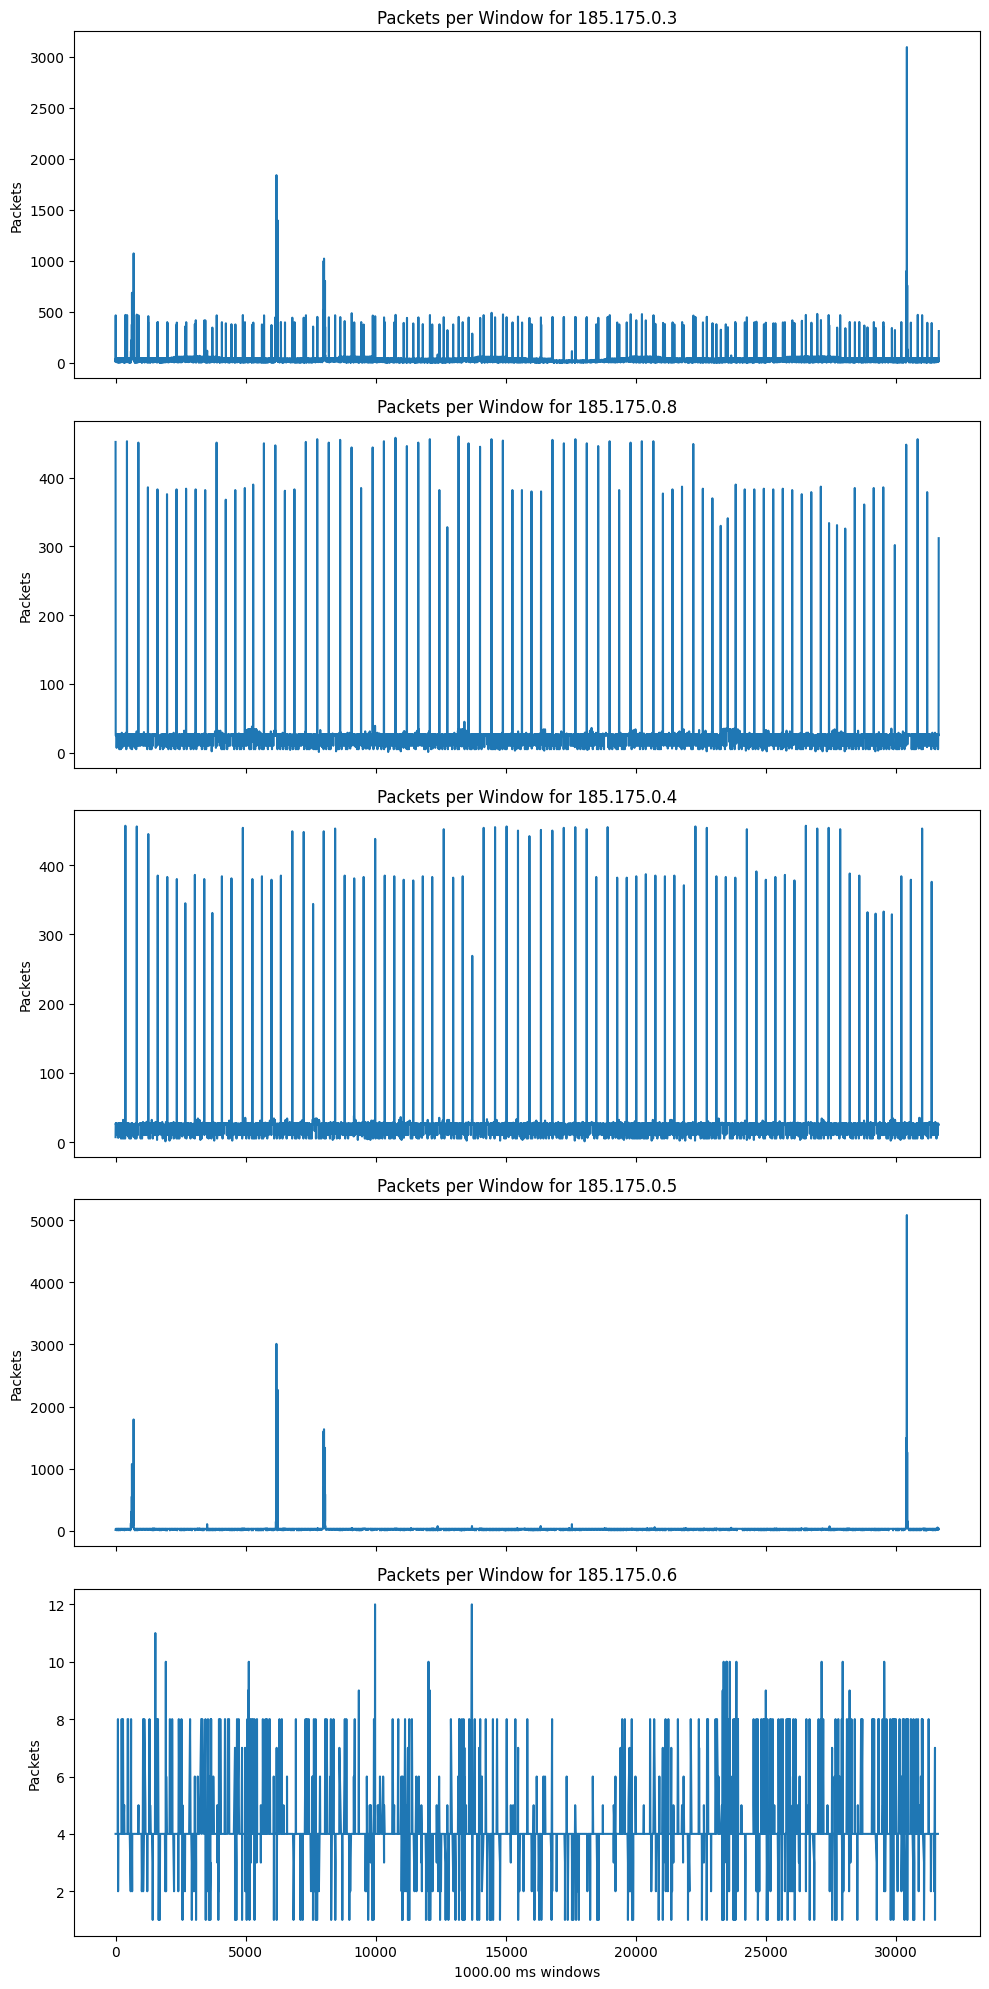

Saved → ../train/1s_cscada_flows.csv



In [ ]:
process_file(1, "../train/cscada_attack_ssw.csv", "../train/1s_cscada_flows.csv")

Processing ../train/ext_attack_nw.csv...


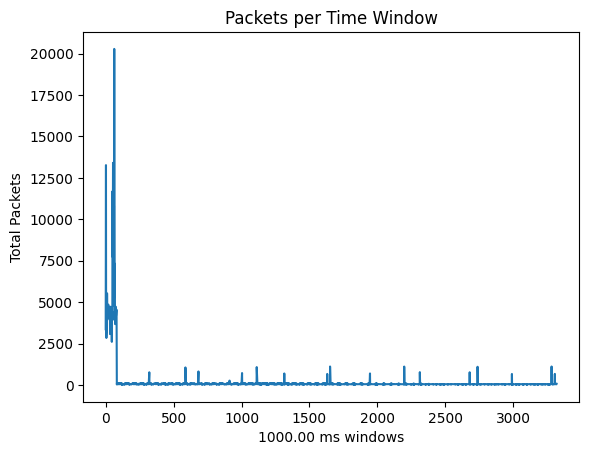

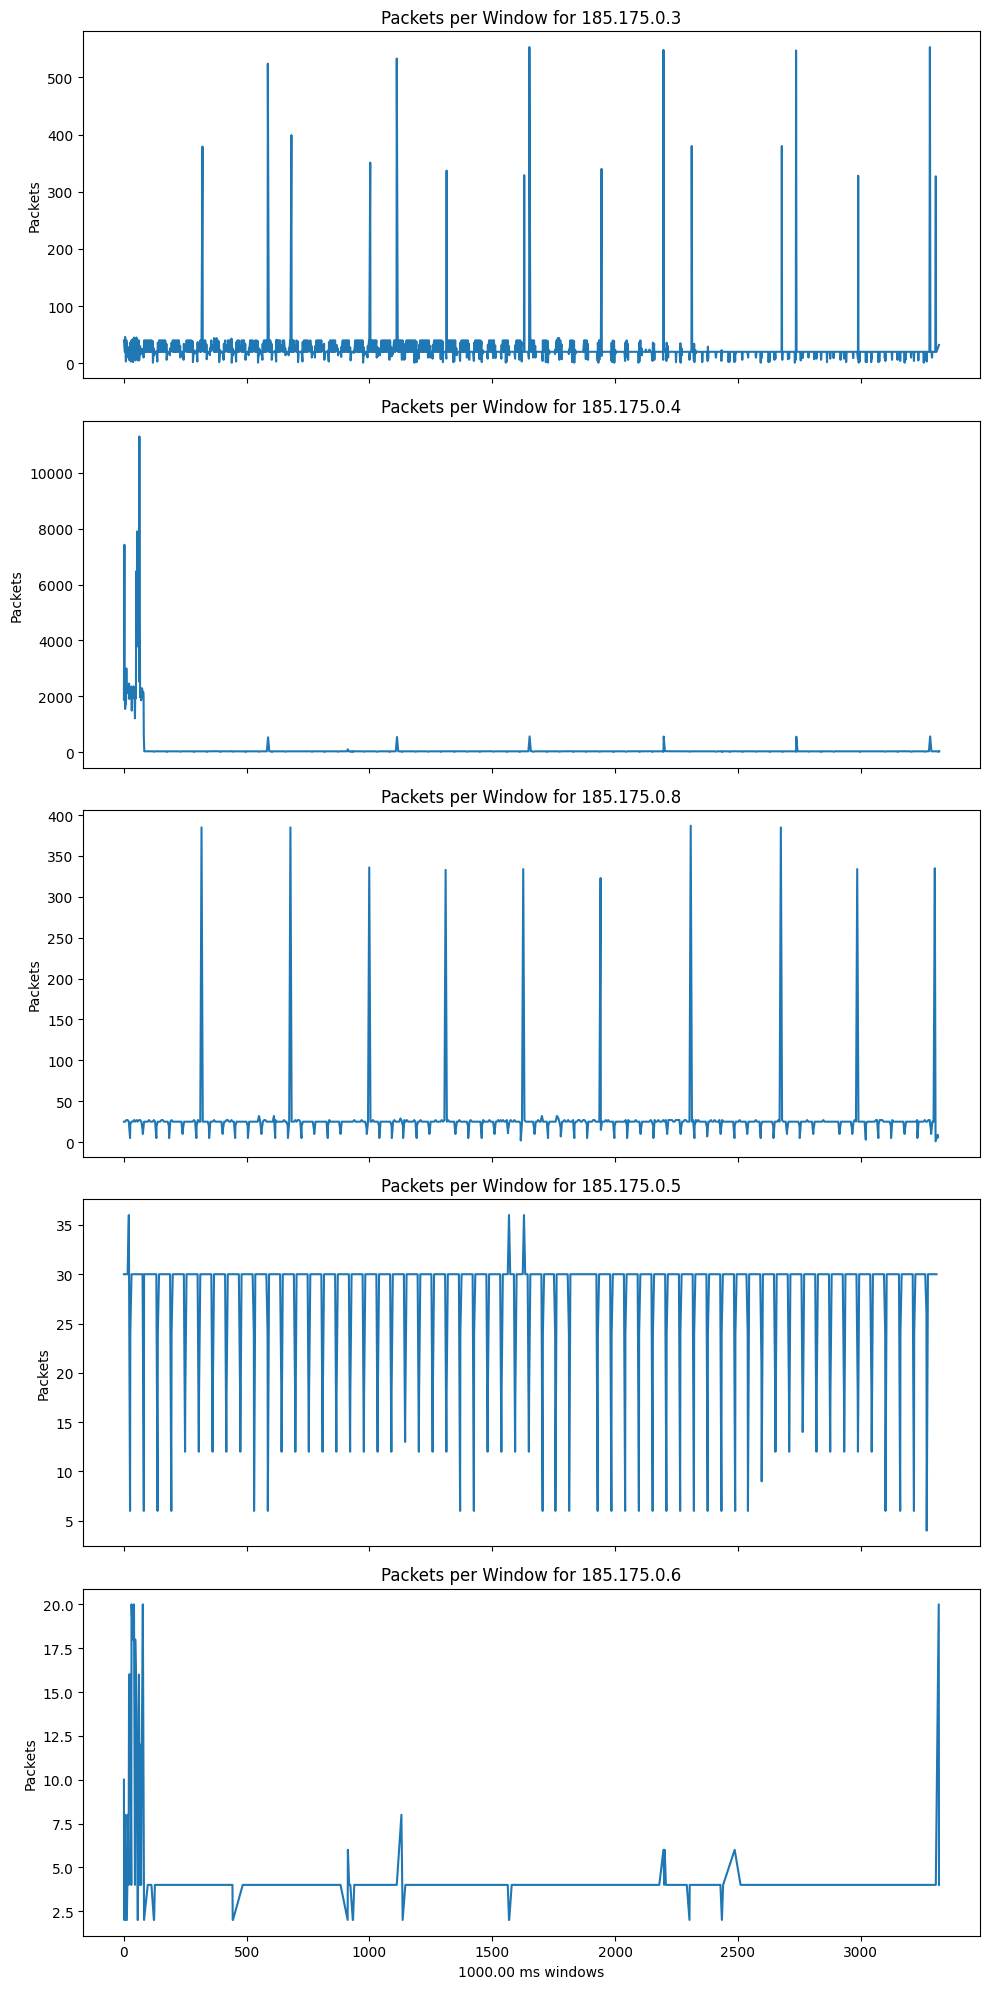

Saved → ../train/1s_external_flows.csv



In [ ]:
process_file(1, "../train/ext_attack_nw.csv", "../train/1s_external_flows.csv")

Processing ../train/benign_nw.csv...


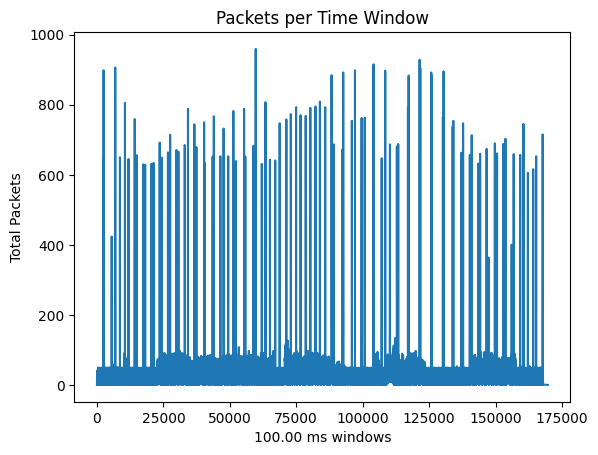

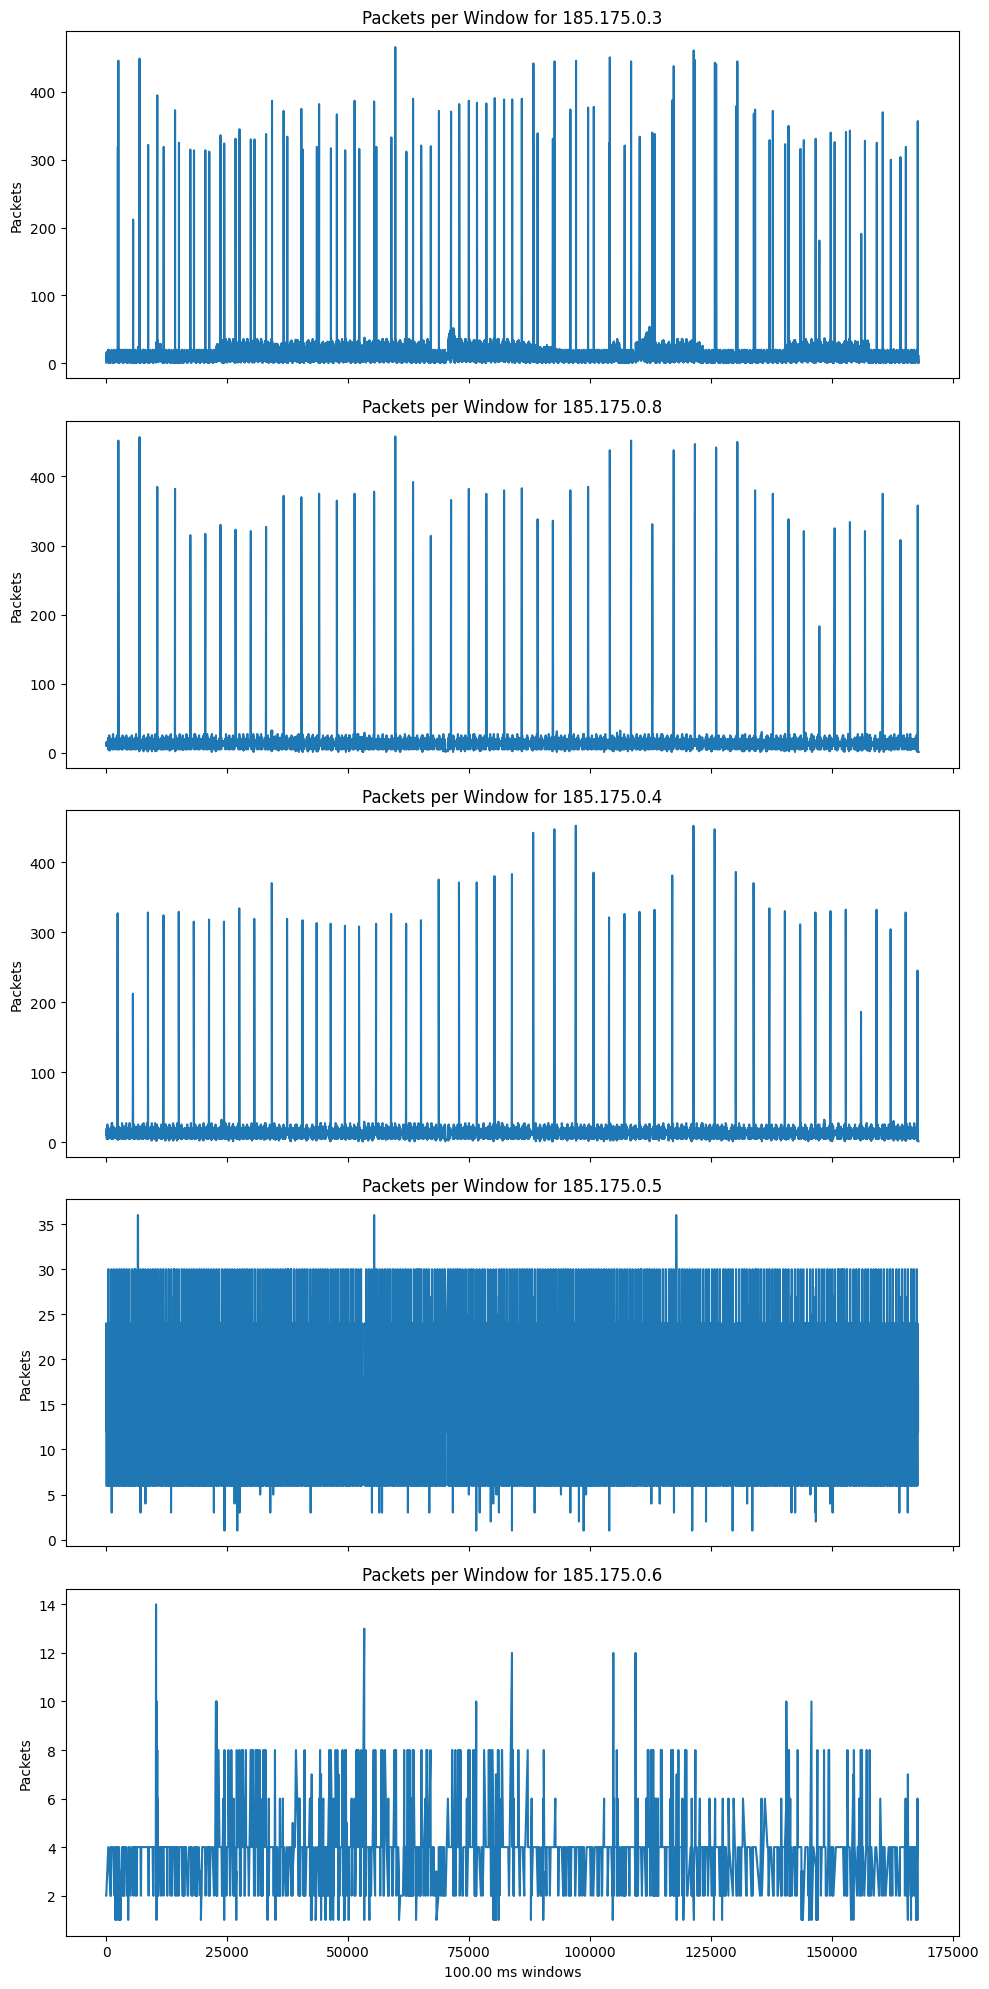

Saved → ../train/100ms_benign_flows.csv



In [ ]:
process_file(10, "../train/benign_nw.csv", "../train/100ms_benign_flows.csv") #this is for one second windows

Processing ../train/cscada_attack_ssw.csv...


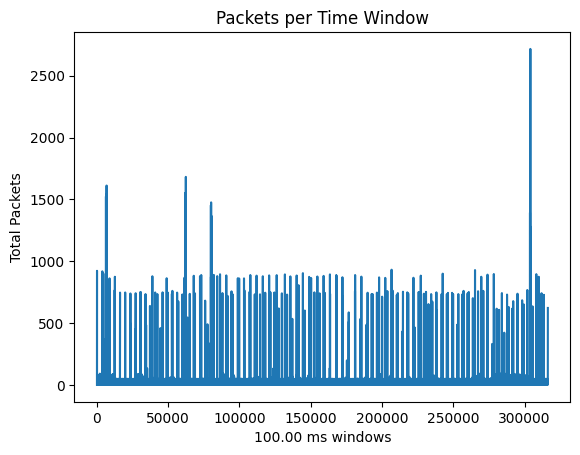

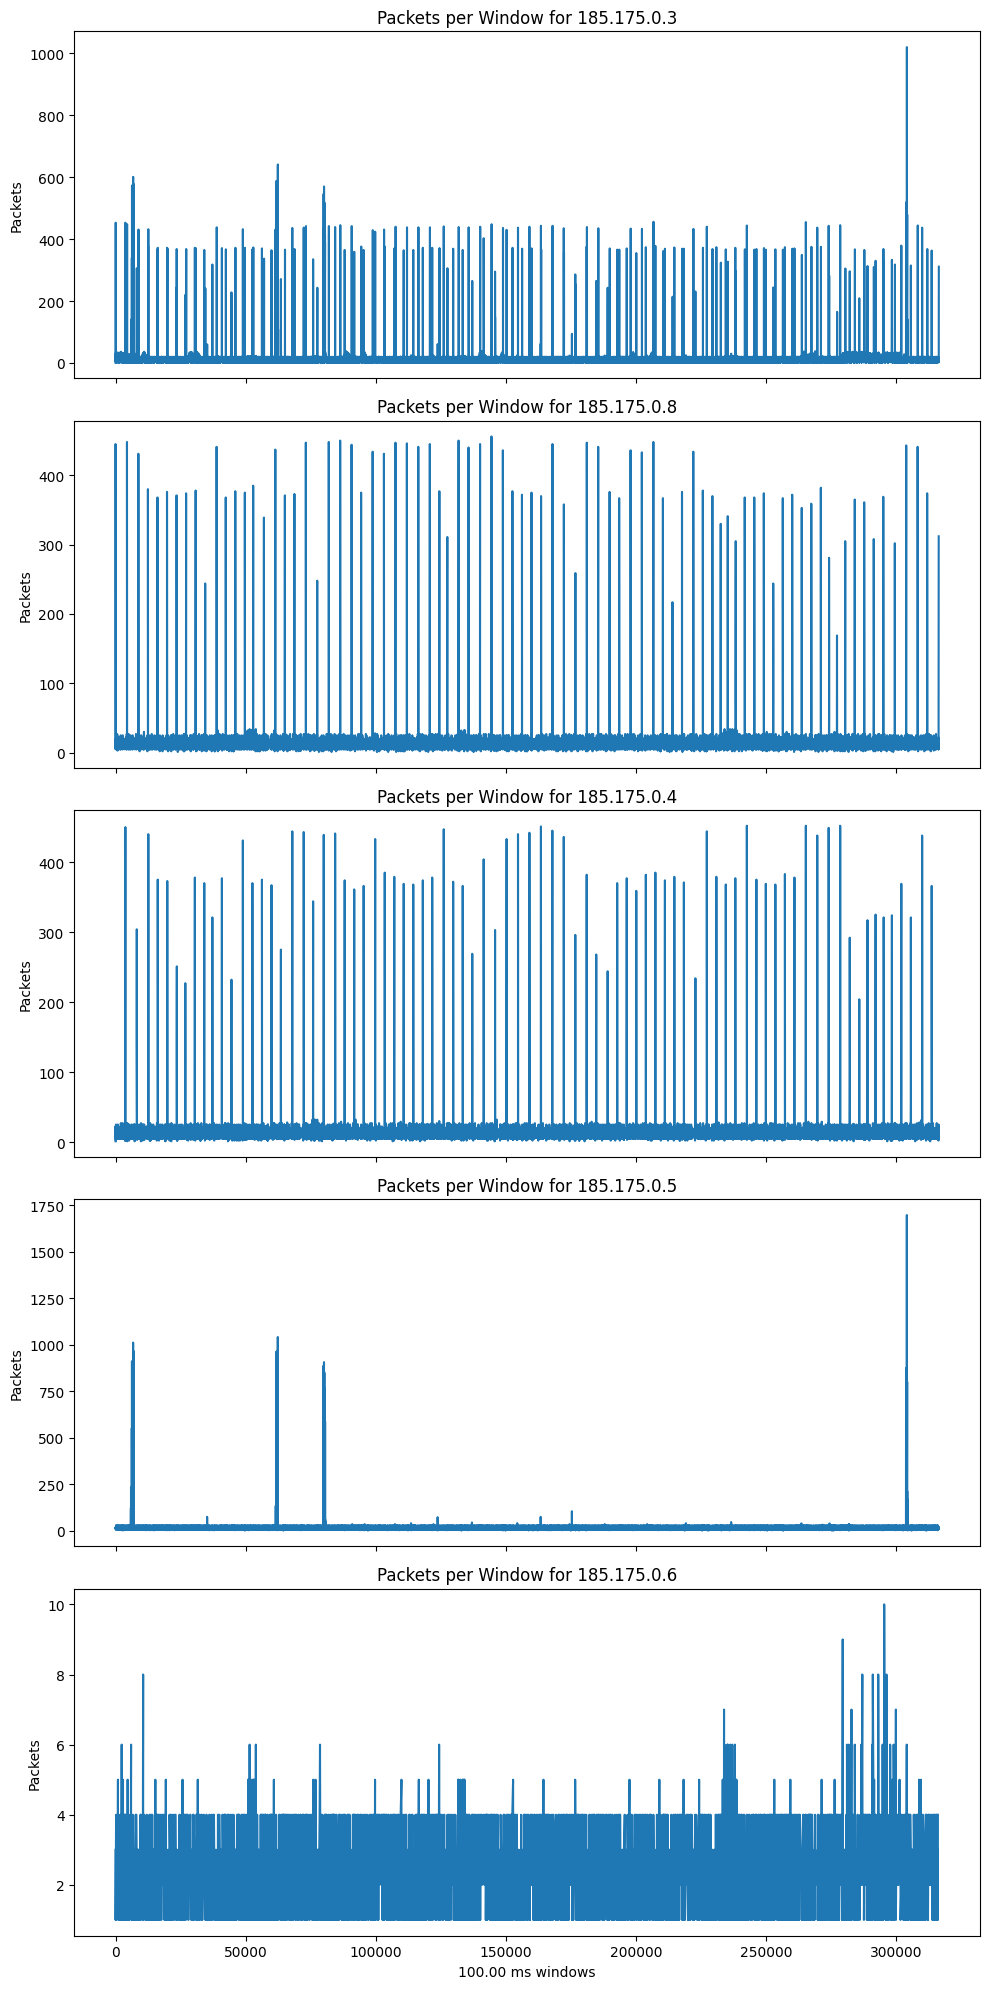

Saved → ../train/100ms_cscada_flows.csv



In [7]:
process_file(10, "../train/cscada_attack_ssw.csv", "../train/100ms_cscada_flows.csv")

Processing ../train/ext_attack_nw.csv...


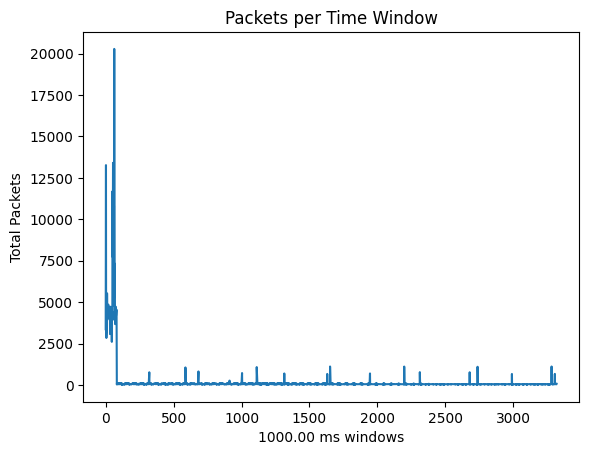

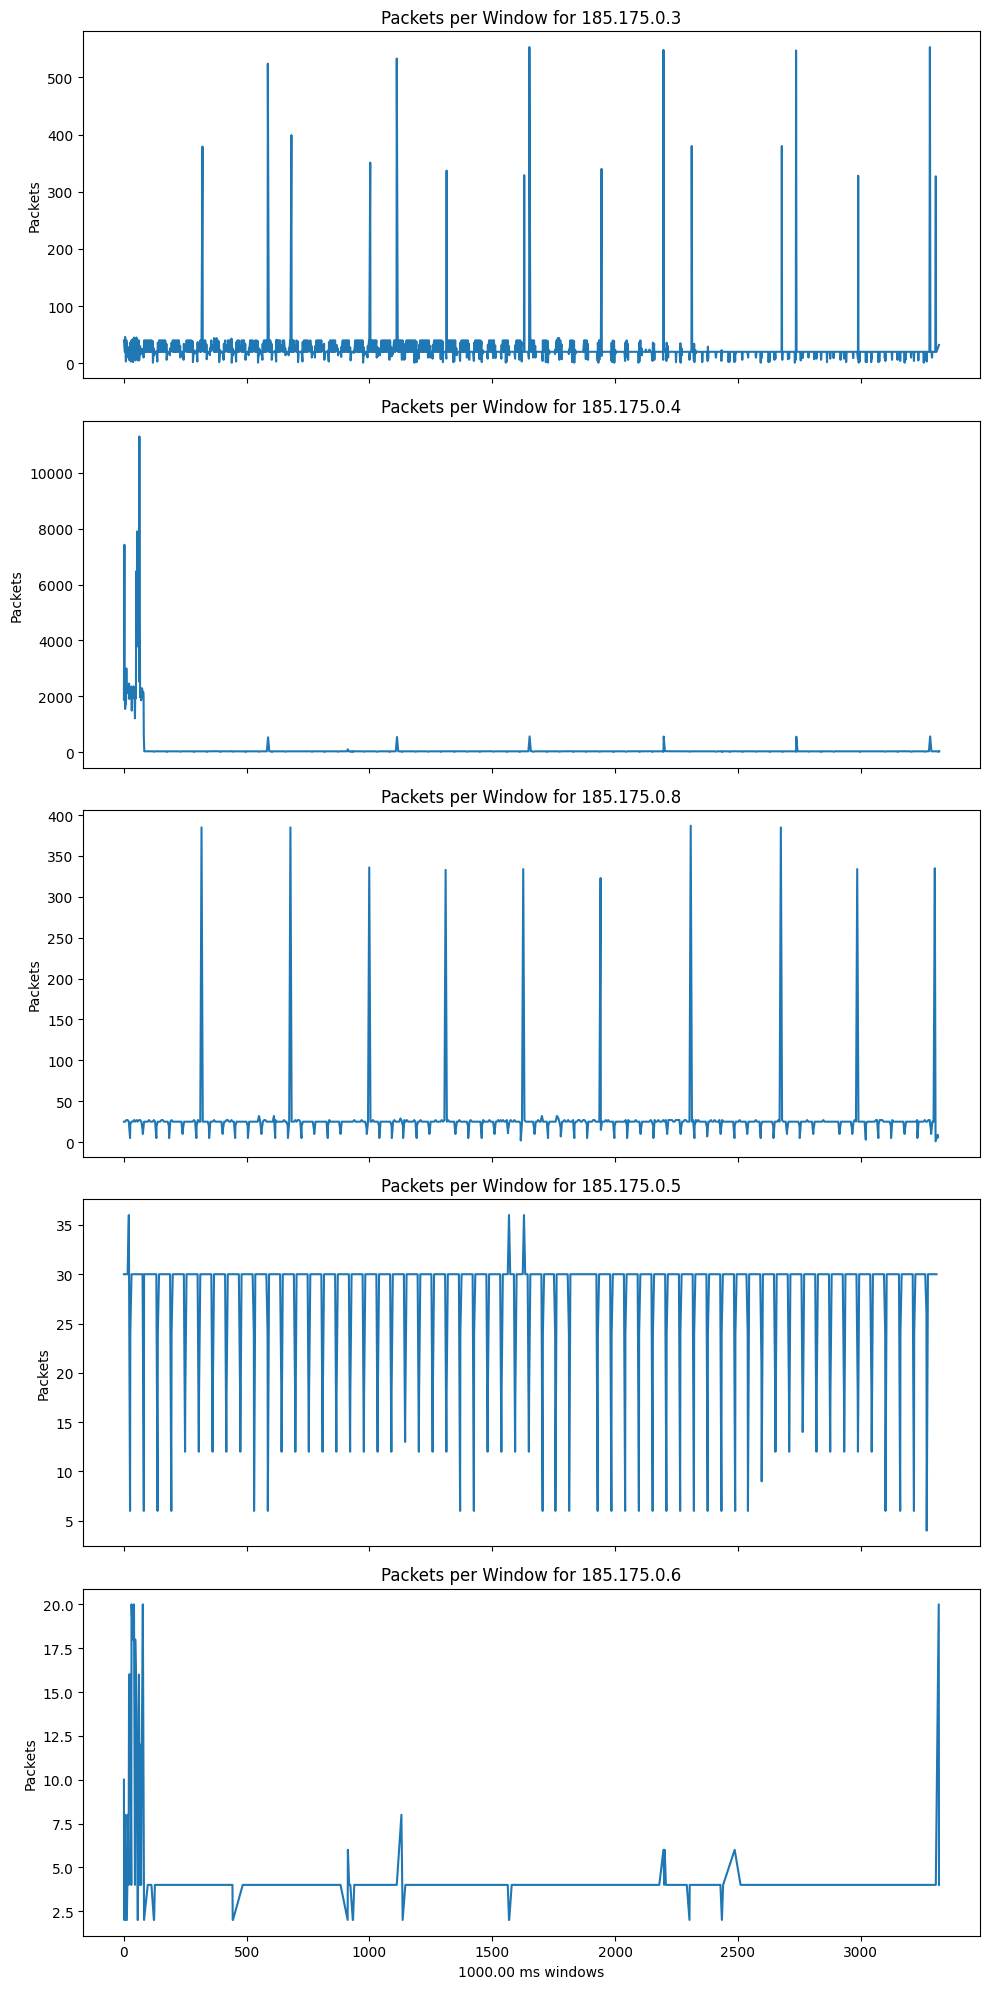

Saved → ../train/100ms_external_flows.csv



In [ ]:
process_file(1, "../train/ext_attack_nw.csv", "../train/100ms_external_flows.csv")